# UMAP 可视化

把 test set 的 embedding 降到 2 维，按 5 个声学参数着色看分布。

颜色平滑过渡的 = embedding 沿那个轴有结构。颜色乱的 = embedding 没编码那个参数。

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
if not os.path.exists('analysis') and os.path.exists('utils.py'):
    os.chdir('..')
sys.path.insert(0, os.path.abspath('analysis'))

import numpy as np
import matplotlib.pyplot as plt
import umap
from utils import load_embeddings, load_continuous_labels, TARGET_NAMES, is_csv_aligned

ENCODERS = ['baseline', 'bewo']
df = load_continuous_labels('test')
cont = df[['DRR', 'C80', 'RT60', 'ILD', 'ITD_ms']].to_numpy(dtype=np.float32)

In [2]:
results = {}
for enc in ENCODERS:
    emb, cls = load_embeddings(enc, 'test')
    if not is_csv_aligned(cls, df):
        print(enc, '没对齐')
        continue
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=0)
    emb2d = reducer.fit_transform(emb)
    results[enc] = emb2d
    print(enc, emb.shape, '->', emb2d.shape)

baseline (140, 128) -> (140, 2)
bewo (140, 512) -> (140, 2)


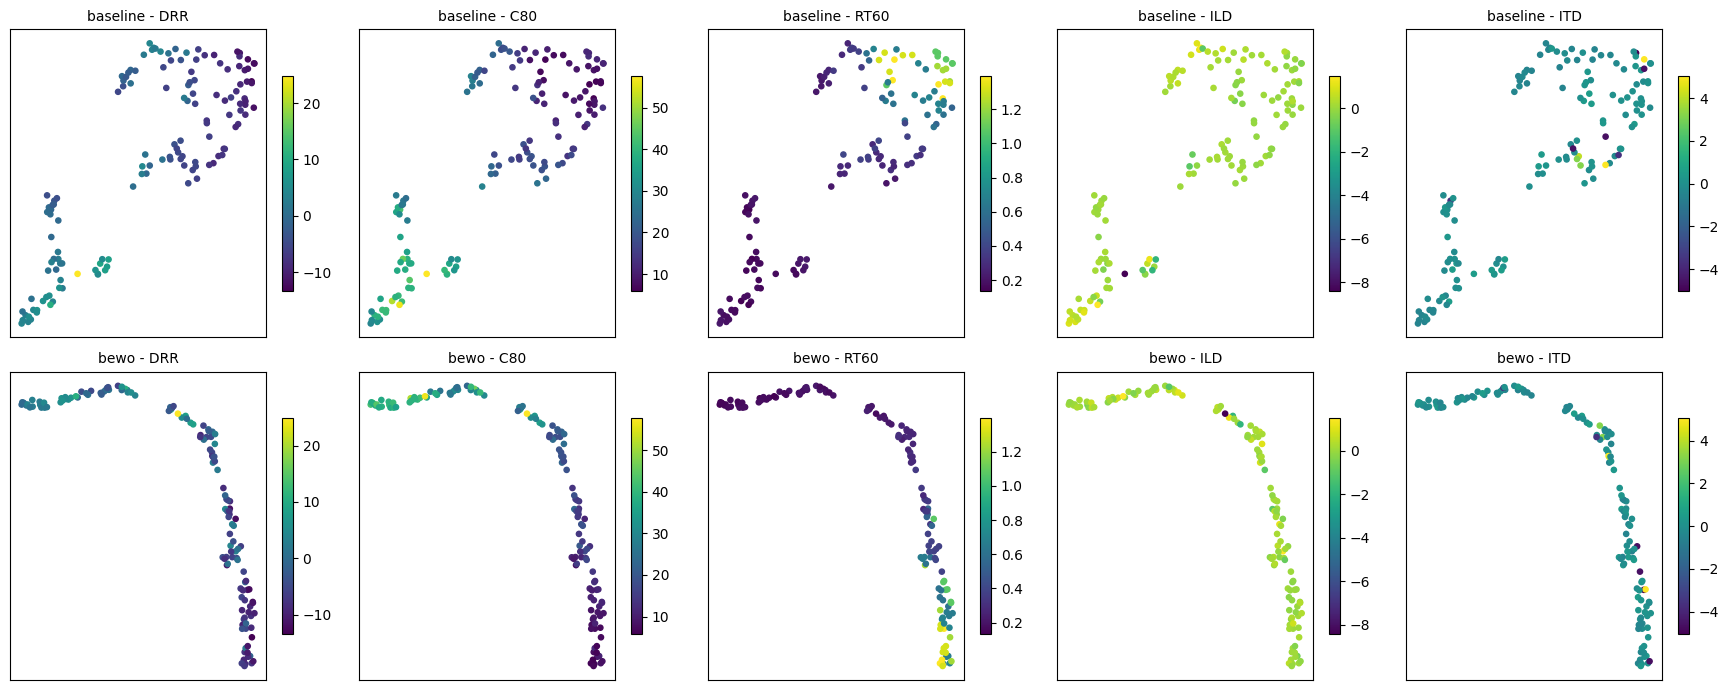

In [3]:
n = len(results)
fig, axes = plt.subplots(n, len(TARGET_NAMES), figsize=(3.5*len(TARGET_NAMES), 3.5*n))
if n == 1:
    axes = axes[None, :]

for r, (enc, emb2d) in enumerate(results.items()):
    for c, t in enumerate(TARGET_NAMES):
        sc = axes[r, c].scatter(emb2d[:, 0], emb2d[:, 1], c=cont[:, c], s=14, cmap='viridis')
        axes[r, c].set_title(f'{enc} - {t}', fontsize=10)
        axes[r, c].set_xticks([])
        axes[r, c].set_yticks([])
        plt.colorbar(sc, ax=axes[r, c], shrink=0.7)

plt.tight_layout()
plt.savefig('analysis/figs/03_umap.png', dpi=120, bbox_inches='tight')
plt.show()

RT60 那一列两个 encoder 都能看出明显的颜色梯度。ILD/ITD 那两列基本是花的。